In [29]:
from dotenv import load_dotenv
from typing import TypedDict , Annotated
from langgraph.graph import StateGraph , START, END
from langchain.chat_models import init_chat_model
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode , tools_condition
load_dotenv()

True

In [30]:
llm = init_chat_model ("google_genai:gemini-2.5-flash")

class chatbot (TypedDict) :
    messages : Annotated[list , add_messages]

In [31]:
@tool
def stock_price(symbol : str) -> float:
    '''give the current price of the stock given the stock symbol 
    : param symbol : stock symbol
    : return current price of the stock'''
    return{
        "MSFT": 200,
        "APL" : 599,
        "samsung" : 600
    }.get(symbol, 0.0)

tools = [stock_price]
llm_with_tools = llm.bind_tools(tools)


In [39]:
def chatbot1(state: chatbot) -> chatbot:
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]
    }

builder = StateGraph(chatbot)

builder.add_node(chatbot1)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot1")
builder.add_conditional_edges("chatbot1" , tools_condition)
builder.add_edge("tools" , "chatbot1")

graph = builder.compile()



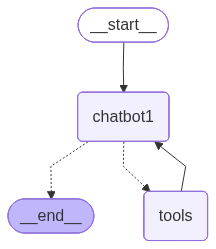

In [41]:
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
state = graph.invoke({"messages" : [{"role" : "user" , "content" :  "What is the price of MSFT stock multiply by 2 right now?"}]})
print(state["messages"][-1].content)


[{'type': 'text', 'text': 'The price of MSFT stock multiplied by 2 is 400.', 'extras': {'signature': 'CtkCAb4+9vtafL27Qw5bslddRa9AkxBRn8Vc+7gZWgBNg9hKPIUPz+leuz7TLby5VL2G1rh9cJ5jX35fC9Du+uEe196QpbBZlmwn8NUxQ3exI8v8nK4DzXc83jPK60bb9tcNsIwGVlKRexwWZt5kN4L3tahT1IJnMBLsmHwFusTNOJPT3KBi3Llc+wo68MfyFUc2sYhPIZHvtdg87tDeF/IDR/jviEKjK99XuhmOHky2NSTdZTppaqpE2Yct3y+J86YN4N8I6IyTV9fLPtlf2dbNPbVKRuFkHRKALo7gGTcCLg5kW4Jd0diySWLZPb1MyuJqBhHbIwhk7EFOTkkVpLOEodHWR5r2jWhqQonz1dufOX43K/tSLXDxad8/ke3LZZn7jIGAYvPA9W884aH5e4MhFs4AmIMipQtKbE3jXwxDqQDqlhlPwrCvrVKHqXazsJV4HT0cOICMGtVy'}}]
